In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy as sp

In [9]:
def sqnorm(x):
    return x.T @ x

In [10]:
def linfunctional(x, a):
    return a.T @ x

In [28]:
def twoquadratic(x):
    return x[0] ** 2 + 2 * x[0] * x[1] + 3 * x[1] ** 2

In [12]:
def quadform(x, A):
    return x.T @ A @ x

In [39]:
def lresidual(x, A, b):
    return 0.5 * (A @ x - b).T @ (A @ x - b)

In [14]:
x = np.array([1.0, 2.0, 3.0])
sqnorm(x)

np.float64(14.0)

In [18]:
def sqnormgrad(x, h):
    x_plus = x.copy()
    x_minus = x.copy()
    res = []
    for i in range(len(x)):
        x_plus[i] += h
        x_minus[i] -= h
        res.append((sqnorm(x_plus) - sqnorm(x_minus))/(2 * h))
        x_plus[i] -= h
        x_minus[i] += h
    return res

sqnormgrad(x, 1e-6)

[np.float64(2.000000000279556),
 np.float64(3.9999999996709334),
 np.float64(6.000000000838668)]

In [21]:
a = np.array([4, 5, 6])
linfunctional(x, a)

np.float64(32.0)

In [24]:
def lfgrad(x, h, a):
    xp = x.copy()
    xm = x.copy()
    res = []
    for i in range(len(x)):
        xp[i] += h
        xm[i] -= h
        res.append((linfunctional(xp, a) - linfunctional(xm, a))/(2 * h))
        xp[i] -= h
        xm[i] += h
    return res

lfgrad(x, 1e-6, a)

[np.float64(4.000000002335469),
 np.float64(5.000000001587068),
 np.float64(5.999999999062311)]

In [30]:
def twoquadgrad(x, h):
    xp = x.copy()
    xm = x.copy()
    res = []
    for i in range(len(x)):
        xp[i] += h
        xm[i] -= h
        res.append((twoquadratic(xp) - twoquadratic(xm))/(2 * h))
        xp[i] -= h
        xm[i] += h
    return res

x = np.array([1.0, 2.0])
twoquadgrad(x, 1e-6)

[np.float64(6.000000000838668), np.float64(14.000000001956892)]

In [32]:
def quadformgrad(x, A, h):
    xp = x.copy()
    xm = x.copy()
    res = []
    for i in range(len(x)):
        xp[i] += h
        xm[i] -= h
        res.append((quadform(xp, A) - quadform(xm, A))/(2 * h))
        xp[i] -= h
        xm[i] += h
    return res

x = np.array([1.0, 2.0])
A = np.array([[2.0, 1.0], [1.0, 3.0]])
quadformgrad(x, A, 1e-6)

[np.float64(8.000000001118224), np.float64(13.999999998404178)]

In [40]:
def lresidualgrad(x, A, b, h):
    xm = x.copy()
    xp = x.copy()
    res = []
    for i in range(len(x)):
        xp[i] += h
        xm[i] -= h
        res.append((lresidual(xp, A, b) - lresidual(xm, A, b))/(2 * h))
        xp[i] -= h
        xm[i] += h
    return res

A = np.array([[1.0, 2.0], [3.0, 4.0], [5.0, 6.0]])
b = np.array([3.0, 7.0, 11.0])
lresidualgrad(x, A, b, 1e-6)

[np.float64(44.00000000615023), np.float64(55.999999997169425)]

In [46]:
x = np.array([3.0, 3.0])
eta = 0.1
xac = []
yac = []
def graddesc(x, eta, itera):
    for i in range(itera):
        grad = np.array([2 * x[0], 4 * x[1]])
        print(x)
        xac.append(x[0])
        yac.append(x[1])
        x = x - eta * grad
    return x

graddesc(x, eta, 50)

[3. 3.]
[2.4 1.8]
[1.92 1.08]
[1.536 0.648]
[1.2288 0.3888]
[0.98304 0.23328]
[0.786432 0.139968]
[0.6291456 0.0839808]
[0.50331648 0.05038848]
[0.40265318 0.03023309]
[0.32212255 0.01813985]
[0.25769804 0.01088391]
[0.20615843 0.00653035]
[0.16492674 0.00391821]
[0.1319414  0.00235092]
[0.10555312 0.00141055]
[0.08444249 0.00084633]
[0.06755399 0.0005078 ]
[0.0540432  0.00030468]
[0.04323456 0.00018281]
[0.03458765 0.00010968]
[2.76701161e-02 6.58108519e-05]
[2.21360929e-02 3.94865112e-05]
[1.77088743e-02 2.36919067e-05]
[1.41670994e-02 1.42151440e-05]
[1.13336796e-02 8.52908641e-06]
[9.06694365e-03 5.11745185e-06]
[7.25355492e-03 3.07047111e-06]
[5.80284393e-03 1.84228266e-06]
[4.64227515e-03 1.10536960e-06]
[3.71382012e-03 6.63221759e-07]
[2.97105609e-03 3.97933055e-07]
[2.37684488e-03 2.38759833e-07]
[1.9014759e-03 1.4325590e-07]
[1.52118072e-03 8.59535400e-08]
[1.21694458e-03 5.15721240e-08]
[9.73555661e-04 3.09432744e-08]
[7.78844529e-04 1.85659646e-08]
[6.23075623e-04 1.11395788

array([4.28174308e-05, 2.42484383e-11])

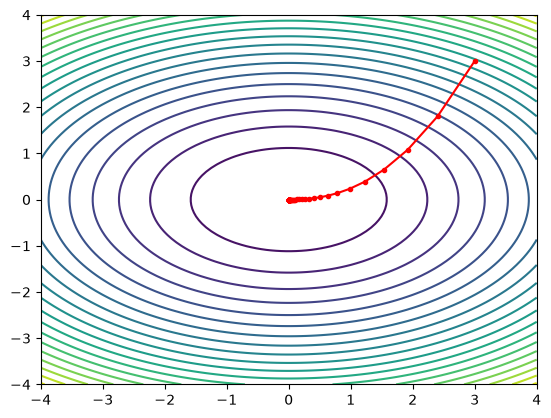

In [48]:
xv = np.linspace(-4, 4, 100)
yv = np.linspace(-4, 4, 100)
X, Y = np.meshgrid(xv, yv)
Z = X ** 2 + 2 * Y ** 2

plt.contour(X, Y, Z, levels = 20)
plt.plot(xac, yac, 'r-o', markersize = 3)

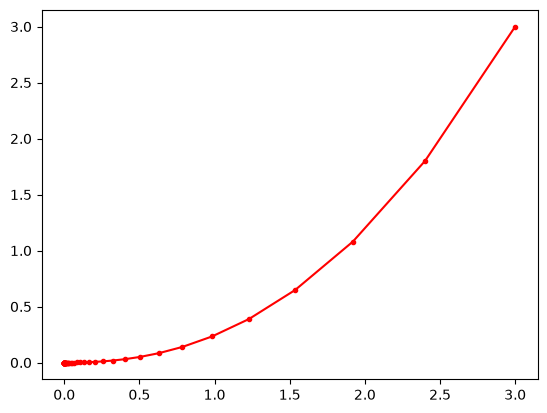

In [47]:
plt.plot(xac, yac, 'r-o', markersize = 3)